<a href="https://colab.research.google.com/github/thornton330j/IS-4487/blob/main/Assignments/assignment_10_ThorntonJackson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS4487 Week 10 - Assignment

### Outline

Our Goals with this Project:

1. Import and review the data
2. Perform EDA and Clean Data
3. Fit a model
4. Test the accuracy of the model
6.  Use the model to predict on a new dataset (without the target)

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_10_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Business Case: AdviseInvest
You work on a small team of data analysts at AdviseInvest, a venture-backed startup. The Director of Sales at AdviseInvest has approached your team asking for help solving a staffing problem.

### The Company
The company's mission is to provide tools and support to help ordinary people gain control of their personal finances. The company leverages technology to provide affordable financial advice to a national client base.

Customers who reach AdviseInvest's website go through five steps:

- Open an account.
- Complete a customer profile form with basic information about their background and finances.
- Schedule a free phone conversation with a sales representative during a 1-hour window of time.
- Attend the free phone conversation.
- Buy a financial plan.
- There are three types of financial plans: Beginner, Intermediate, and Advanced. Each is sold at a different price, and there are varying degrees of personalization. After a customer purchases a financial plan, the customer is assigned a financial planner who helps determine the customer's goals and advises the customer on spending decisions.

### The Problem
Some customers are lost at each stage of the process. Steps 3 and 4 are particularly challenging because approximately 50% of those who schedule a phone conversation fail to pick up the call. This leads to inefficiencies from a staffing perspective.

AdviseInvest has 4 sales reps on staff during each particular 1-hour window. Each of the 4 reps is assigned 2 prospective customers per hour, which means that the company schedules a total of 8 phone calls per hour. The calls are outgoing: sales reps call customers who scheduled a phone conversation during that hour window.

Unfortunately, as noted above, many of the customers who scheduled a call do not answer. As a consequence, sales reps are often left underutilized. Moreover, they are underutilized unevenly. For example, it is possible that one sales rep will not do any sales calls during that hour, whereas another will be busy the entire hour with two calls. Sales reps have nothing to do when customers do not answer the scheduled phone call.

### AdviseInvest Data Dictionary


| Variable | Description | Type | Code |
|:---|:---|:---|:---|
| customer_id | Unique customer identifier | Numeric | |
| Answered | Customer response | Binary | 0: customer did not answer scheduled call; 1: customer answered scheduled call |
| Income | Customer income in US dollars | Numeric | |
| Female | Customer gender | Binary | 0: female; 1: male |
| Age | Age in years | Numeric | |
| Job | Nature of job | Categorical | 0 : unemployed; 1 : entry level position; 2 : midlevel position; 3 : management/ self-employed/ highly qualified employee/ officer |
| Num_dependents | Number of people for whom the customer provides maintenance | Numeric | |
| Rent | Customer rents | Binary | 0: no; 1: yes |
| Own_res | Customer owns residence | Binary | 0: no; 1: yes |
| New_car | Recent new car purchase | Binary | New car purchase in the last 3 months: 0: no, 1: yes |
| Chk_acct | Checking account status | Categorical | 0 : no checking account; 1: checking < 200 USD; 2 : 200 < checking < 2000 USD; 3: 2000 < checking < 35000 USD; 4: >= 3500 USD |
| Sav_acct | Average balance in savings account | Categorical | 0 : no savings account; 1 : 100 <= savings < 500 USD; 2 : 500 <= savings < 2000 USD; 3 : 2000 < savings < 35000 USD; 4: >= 3500 USD |
| Num_accts | Number of accounts owned by customer | Numeric | |
| Mobile | Mobile phone | Binary | 0: customer provided non‐mobile phone for follow‐up call; 1: customer provided mobile phone for follow‐up call |
| Product | Type of product purchased after conversation with sales rep | Categorical | 0: customer did not answer call; 1: customer answered but did not purchase a product; 2: customer answered and purchased Beginner plan; 3: customer answered and purchased Intermediate plan; 4: customer answered and purchased Advanced plan |

### Load Libraries

Import the libraries you will need, such as:
- Pandas
- Sklearn
- Matplotlib


In [1]:
# Import libraries 🔧
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

## Step 1: Initial Data Understanding

### Do the following:
 - Import data from the AdviseInvest historical dataset into a dataframe (in GitHub go to the DataSets folder and look for `adviseinvest_historical_data.csv`)
 - Describe or profile the dataframe
 - Look for any outliers, missing values, or duplicates

In [3]:
#Import the data 🔧
url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/adviseinvest_historical_data.csv'
df = pd.read_csv(url)
print("Data loaded successfully into DataFrame 'df'. First 5 rows:")
df.head()

Data loaded successfully into DataFrame 'df'. First 5 rows:


,customer_id,answered,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
0,10098,0,-65600,0,24,2,1,0,1,1.0,1,1,3,0,0
1,184,0,4330,0,24,2,2,1,0,0.0,1,3,1,0,0
2,194,0,4330,0,22,2,1,1,0,0.0,3,0,0,0,0
3,689,0,4330,0,24,2,2,1,0,0.0,1,3,1,0,0
4,811,0,4330,0,22,2,1,1,0,0.0,3,0,0,0,0


In [100]:
#View the datatypes 🔧
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29504 entries, 0 to 29503
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     29504 non-null  int64  
 1   answered        29504 non-null  int64  
 2   income          29504 non-null  int64  
 3   female          29504 non-null  int64  
 4   age             29504 non-null  int64  
 5   job             29504 non-null  int64  
 6   num_dependents  29504 non-null  int64  
 7   rent            29504 non-null  int64  
 8   own_res         29504 non-null  int64  
 9   new_car         29504 non-null  float64
 10  chk_acct        29504 non-null  int64  
 11  sav_acct        29504 non-null  int64  
 12  num_accts       29504 non-null  float64
 13  mobile          29504 non-null  int64  
 14  product         29504 non-null  int64  
dtypes: float64(2), int64(13)
memory usage: 3.4 MB


In [6]:
#Describe the data 🔧
df.describe()

,customer_id,answered,income,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
count,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29502.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000
mean,14850.475563,0.546638,33766.893303,34.773454,1.915401,1.140998,0.210412,0.681128,0.240797,1.468547,0.956616,2.458345,0.091106,1.535792
std,8517.254310,0.497829,29379.202710,11.369865,0.658183,0.348025,0.407608,0.466047,0.427575,1.234727,1.483946,19.497380,0.287765,1.625916
min,99.000000,0.000000,-65600.000000,19.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7474.750000,0.000000,13550.000000,26.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000
50%,14850.500000,1.000000,23310.000000,32.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,1.000000
75%,22226.250000,1.000000,41690.000000,40.000000,2.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,3.000000
max,29602.000000,1.000000,159450.000000,132.000000,3.000000,2.000000,1.000000,1.000000,1.000000,3.000000,4.000000,3345.000000,1.000000,4.000000


## Step 2: Data Preparation

### 2.1: Data Cleanup
- Check for and remove any outliers
- Consider fixing any missing data (should you delete the record or impute the value?)
- Clean up the data and put it in a new dataframe named "df_clean"


In [98]:
#delete outliers 🔧
for column in ['income', 'age', 'num_accts']:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

# Cap outliers
df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)

In [99]:
#cleanup any missing or non-standardized data 🔧
print("Checking for missing values before cleaning:")
print(df.isnull().sum())

# Handle missing values
mode_new_car = df['new_car'].mode()[0]
df['new_car'] = df['new_car'].fillna(mode_new_car)
print(f"'new_car' missing values imputed with mode: {mode_new_car}")

# Clean 'female' column - convert to numerical binary
print(f"Unique values in 'female' column before cleaning: {df['female'].unique()}")

# Convert to integer
df['female'] = pd.to_numeric(df['female'], errors='coerce')

# Convert to string first to handle mixed types
df['female'] = df['female'].astype(str).map({'0': 0, '1': 1, 'M': 1, 'F': 0}).fillna(0).astype(int)
print(f"Unique values in 'female' column after cleaning: {df['female'].unique()}")

print("Checking for missing values after cleaning:")
print(df.isnull().sum())

# Create df_clean
df_clean = df.copy()
print("df_clean created with cleaned data. First 5 rows:")
print(df_clean.head())

Checking for missing values before cleaning:
customer_id       0
answered          0
income            0
female            0
age               0
job               0
num_dependents    0
rent              0
own_res           0
new_car           0
chk_acct          0
sav_acct          0
num_accts         0
mobile            0
product           0
dtype: int64
'new_car' missing values imputed with mode: 0.0
Unique values in 'female' column before cleaning: [0]
Unique values in 'female' column after cleaning: [0]
Checking for missing values after cleaning:
customer_id       0
answered          0
income            0
female            0
age               0
job               0
num_dependents    0
rent              0
own_res           0
new_car           0
chk_acct          0
sav_acct          0
num_accts         0
mobile            0
product           0
dtype: int64
df_clean created with cleaned data. First 5 rows:
   customer_id  answered  income  female  age  job  num_dependents  rent  \
0   

### 2.2: Standardize variables

 - Change "answered" to a boolean (true/false) type
 - Convert any variables that should be an integer into an integer

In [35]:
# Convert answered to boolean 🔧
df_clean['answered'] = df_clean['answered'].astype(bool)

In [36]:
# Convert variables to integer data type 🔧
df_clean['new_car'] = df_clean['new_car'].astype(int)
df_clean['num_accts'] = df_clean['num_accts'].astype(int)

### 2.3 Convert variables to categorical

- Find at least 8 variables that would be appropriate to convert to categories

In [47]:
#Convert categorical variables 🔧
categorical_cols = ['female', 'job', 'num_dependents', 'rent', 'own_res', 'new_car', 'chk_acct', 'sav_acct', 'mobile', 'product']

for col in categorical_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('category')
print(categorical_cols)
print("Data types after conversion:")
print(df_clean[categorical_cols].dtypes)

['female', 'job', 'num_dependents', 'rent', 'own_res', 'new_car', 'chk_acct', 'sav_acct', 'mobile', 'product']
Data types after conversion:
female            category
job               category
num_dependents    category
rent              category
own_res           category
new_car           category
chk_acct          category
sav_acct          category
mobile            category
product           category
dtype: object


# Step 3: Exploratory Data Analysis (EDA)

### Do the following:
- Explore the relationships between the target and independent variables
- Create at least five charts to show the relationships, using different chart types that are approriate to the analysis
- Ensure that all charts are clearly labeled and formatted



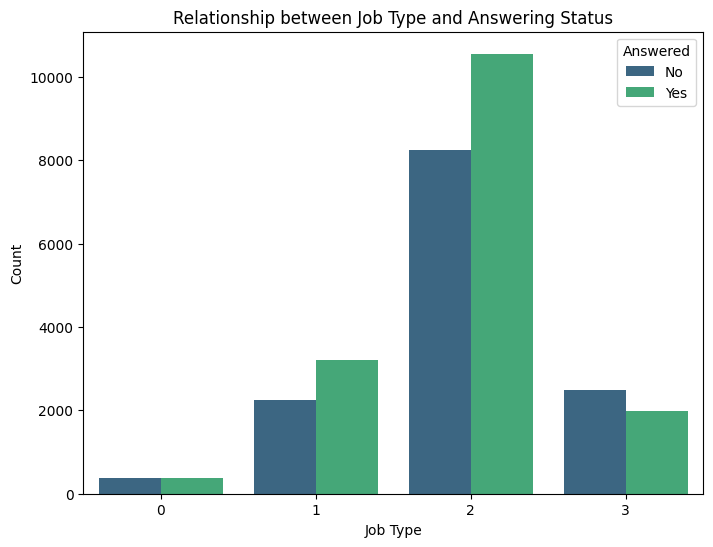

In [49]:
# Chart 1: Relationship between 'job' and 'answered' 🔧
plt.figure(figsize=(8, 6))
sns.countplot(data=df_clean, x='job', hue='answered', palette='viridis')
plt.title('Relationship between Job Type and Answering Status')
plt.xlabel('Job Type')
plt.ylabel('Count')
plt.legend(title='Answered', labels=['No', 'Yes'])
plt.show()

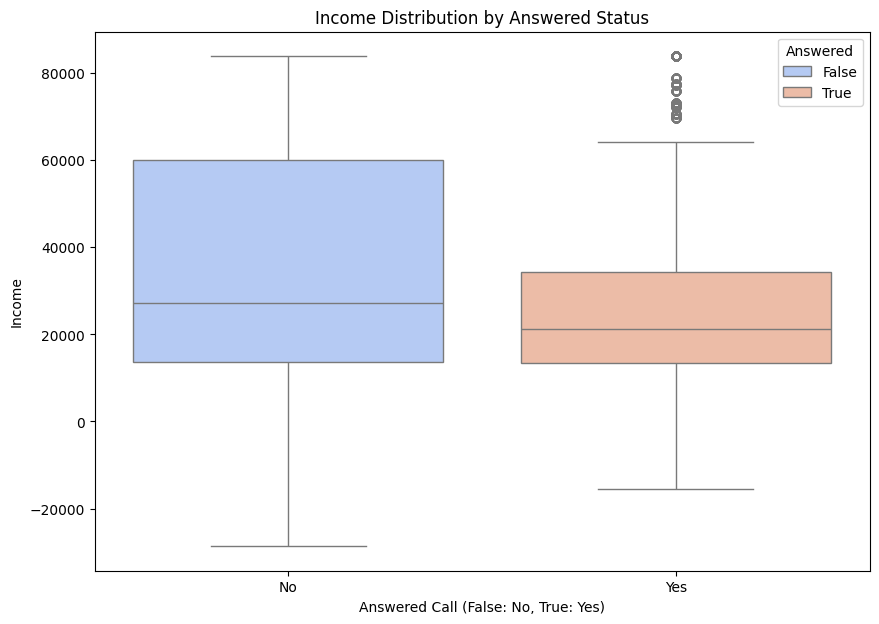

In [51]:
# Chart 2: Income vs. Answered 🔧
plt.figure(figsize=(10, 7))
sns.boxplot(data=df_clean, x='answered', y='income', hue='answered', palette='coolwarm')
plt.title('Income Distribution by Answered Status')
plt.xlabel('Answered Call (False: No, True: Yes)')
plt.ylabel('Income')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.legend(title='Answered')
plt.show()

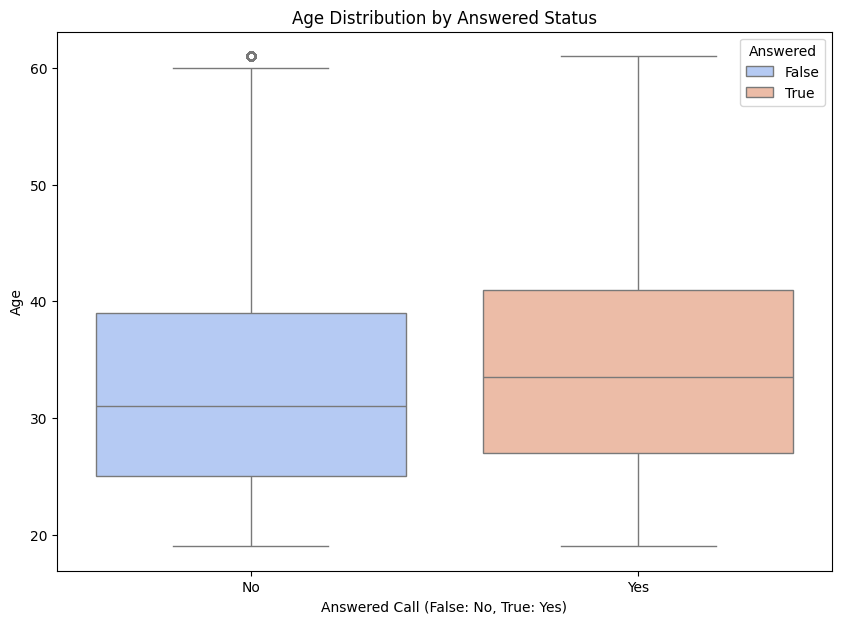

In [52]:
# Chart 3: Age vs. Answered 🔧
plt.figure(figsize=(10, 7))
sns.boxplot(data=df_clean, x='answered', y='age', hue='answered', palette='coolwarm')
plt.title('Age Distribution by Answered Status')
plt.xlabel('Answered Call (False: No, True: Yes)')
plt.ylabel('Age')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.legend(title='Answered')
plt.show()

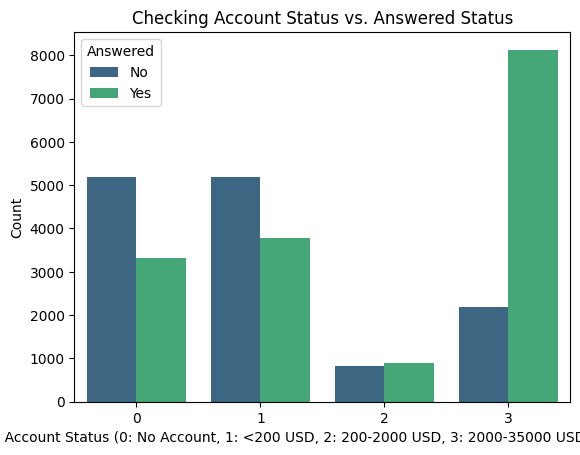

In [53]:
# Chart 4: Checking Account Status vs. Answered 🔧
sns.countplot(data=df_clean, x='chk_acct', hue='answered', palette='viridis')
plt.title('Checking Account Status vs. Answered Status')
plt.xlabel('Checking Account Status (0: No Account, 1: <200 USD, 2: 200-2000 USD, 3: 2000-35000 USD, 4: >=3500 USD)')
plt.ylabel('Count')
plt.legend(title='Answered', labels=['No', 'Yes'])
plt.show()

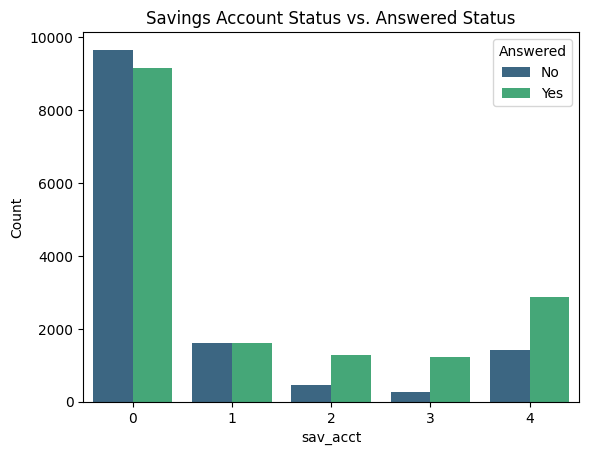

In [56]:
# Chart 5: Savings Account Status vs. Answered 🔧
sns.countplot(data=df_clean, x='sav_acct', hue='answered', palette='viridis')
plt.title('Savings Account Status vs. Answered Status')
plt.ylabel('Count')
plt.legend(title='Answered', labels=['No', 'Yes'])
plt.show()

## Step 4: Modeling

### 4.1: Calculate the base probability of answering

If we use no model at all, how good is our chance of predicting someone leaving?  Use a calculation to find the chances of someone leaving.

In [97]:
#get the default probability 🔧
base_probability_answered = df_clean['answered'].mean()
print(f"Base probability of a customer answering the call: {base_probability_answered:.4f}")

Base probability of a customer answering the call: 0.5466


### 4.2: Split the training and testing datasets

- split df_clean using train_test_split function
- all variables except answered should be in the x variable
- answered is in the y variable


In [96]:
# Split data into training and testing sets 🔧
from sklearn.model_selection import train_test_split

# Define features and target
X = df_clean.drop(['answered', 'customer_id'], axis=1)
y = df_clean['answered']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Data split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets successfully.
X_train shape: (20652, 13)
X_test shape: (8852, 13)
y_train shape: (20652,)
y_test shape: (8852,)


### 4.3: Create a Decision Tree
- Use all available attributes (except those that were eliminated in step 3)
- It is recommended to use the type "entropy" and a max_depth of 4

In [95]:
#create a tree  🔧
# Create a Decision Tree classifier
dtree = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

# Train the model
dtree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

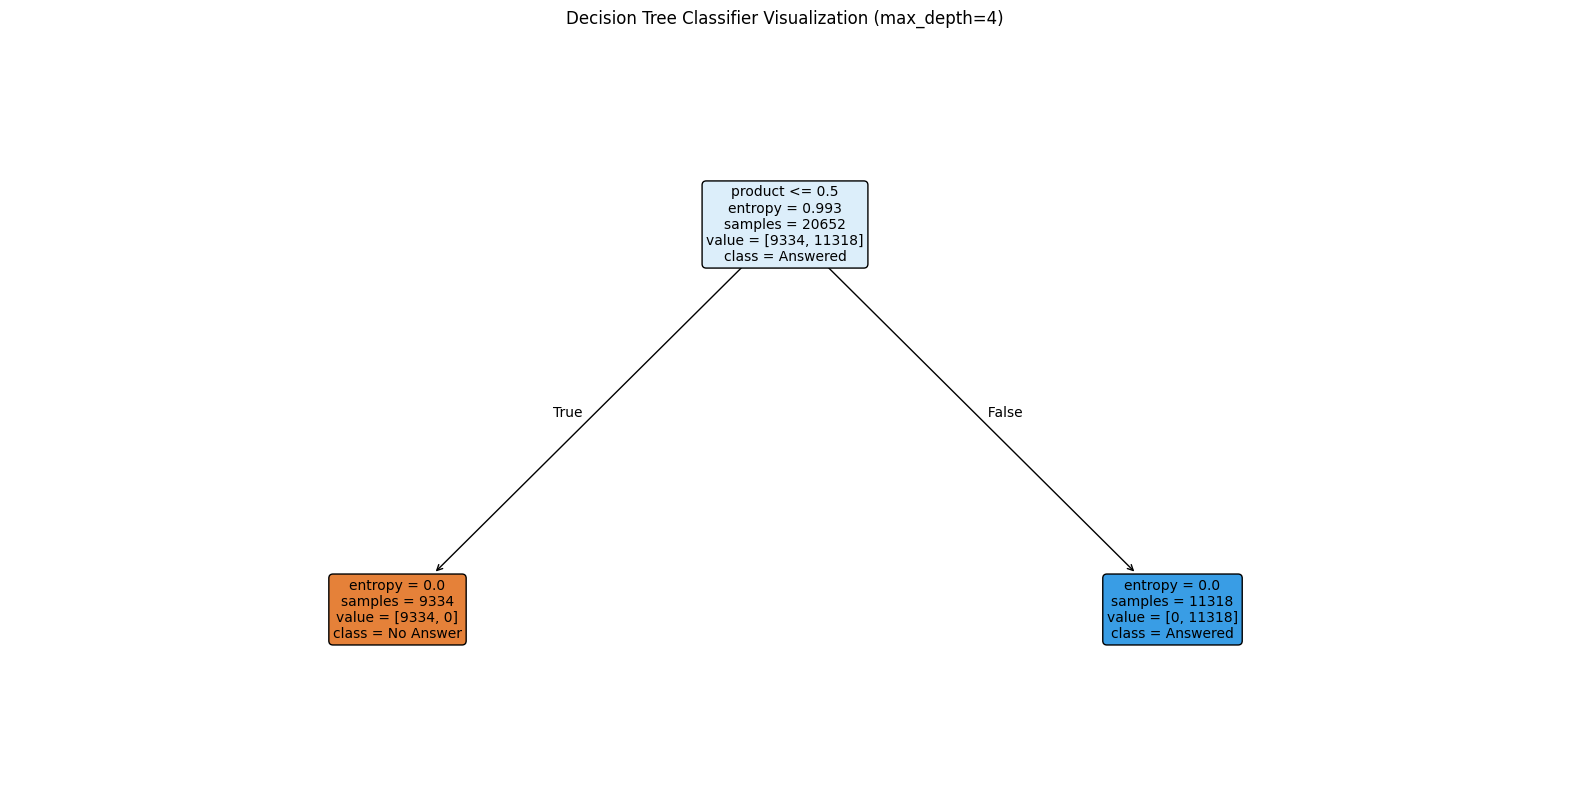

In [94]:
#display (visualize) the tree 🔧
plt.figure(figsize=(20,10))
plot_tree(dtree, filled=True, feature_names=X.columns, class_names=['No Answer', 'Answered'], rounded=True, fontsize=10)
plt.title('Decision Tree Classifier Visualization (max_depth=4)')
plt.show()

### 4.4: What is the accuracy?

This should be better than the base probability, or you have failed in your objective

In [93]:
#calculate the probability for your tree 🔧
from sklearn.metrics import accuracy_score

# Make predictions on the test set
y_pred = dtree.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Decision Tree Model Accuracy: {accuracy:.4f}")

Decision Tree Model Accuracy: 1.0000


### 4.5: Create a confusion matrix

This will show false positives, true positives, etc.

In [92]:
#create a basic confusion matrix 🔧
from sklearn.metrics import confusion_matrix

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[4042    0]
 [   0 4810]]


Create a more visual, interpretable version of the matrix

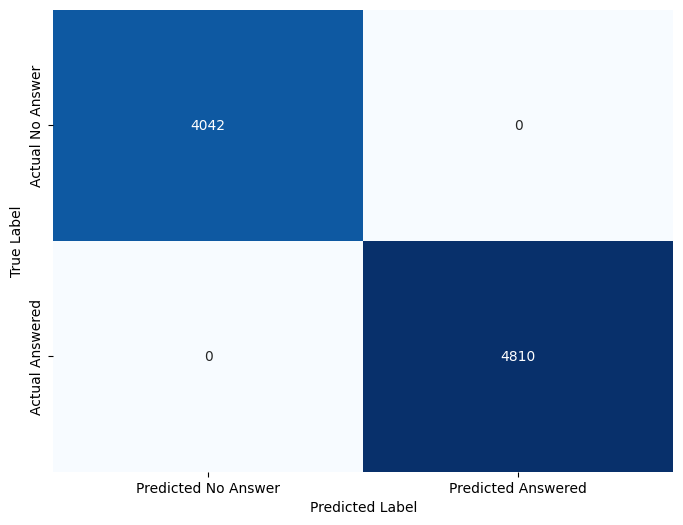

In [91]:
#Create a beautiful matrix; hint - try using Seaborn Heatmap 🔧
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No Answer', 'Predicted Answered'],
            yticklabels=['Actual No Answer', 'Actual Answered'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Step 5: Evaluate the Model

**Assumptions**

One of the simplifying assumptions we will make in this project is that all the customers who answer the phone will purchase a product. (This assumption is actually verified by the data.) To model "answered" in this case is therefore equivalent to modeling "purchased."

There are costs and benefits in this case. We will assume that customers purchase a product for 100 dollars. This was the average cost of AdviseInvest products, according to the Director of Sales.  Also, as we learned in the interview, the agent time to make the sale is worth 25 dollars. Profit would therefore be \$75 dollars for an answered call and a purchase. In sum:

**Benefit**: True positive. The customer is predicted to answer, does answer, and purchases a product for 100 dollars for a profit of 100 - 25 = 75.

**Cost**: False positive. The customer is predicted to answer, but does not answer, so there is a loss of 25. (We assume the agent cannot schedule another call at the last minute, or spends the entire time slot trying to make the call.)

When you create a calculation you can use:
- True answered * 75 -> These people purchased
- False answered * 25 -> You can't schedule another call

For this exercise, we propose that customers who are not predicted to answer will not be called, so there would be no benefits and no costs for them.  

### 5.1 Calculate the Profit Using the Model

In [90]:
# Write a calcuation for the profit from your model 🔧
# Benefit from a true positive
profit_per_tp = 75

# Cost from a false positive
cost_per_fp = 25

# Confusion Matrix
true_negatives = cm[0, 0]
false_positives = cm[0, 1]
false_negatives = cm[1, 0]
true_positives = cm[1, 1]

# Calculate profit from the model
profit_model = (true_positives * profit_per_tp) - (false_positives * cost_per_fp)

print(f"Profit using the Decision Tree model: ${profit_model:.2f}")

Profit using the Decision Tree model: $360750.00


### 5.2 Compare to the Default Profit

How much profit (revenue - costs) could be expected if all customers are called? We can consider this a baseline case for profit since it does not require a model.

In other words, to calculate profit in this baseline scenario treat the customers who answer as true positives treat the customers who do not answer as false positives.

In [89]:
#Write a calculation for the overall profit without using the model (default) 🔧
total_customers_test = len(y_test)
num_answered_actual = y_test.sum()
num_not_answered_actual = total_customers_test - num_answered_actual
profit_default = (num_answered_actual * profit_per_tp) - (num_not_answered_actual * cost_per_fp)

print(f"Profit if all customers are called (default scenario): ${profit_default:.2f}")

Profit if all customers are called (default scenario): $259700.00


### 5.3 Tune the Model
- Adjust the size or shape of the tree, then test the accuracy
- Keep changing these parameters until you end up with a tree with accuracy that is better than the initial model

In [88]:
# Create a new version of the tree with new parameters 🔧

# Create a new Decision Tree classifier with adjusted parameters
dtree_tuned = DecisionTreeClassifier(criterion='entropy', max_depth=6, random_state=42)

# Train the tuned model
dtree_tuned.fit(X_train, y_train)

# Make predictions on the test set with the tuned model
y_pred_tuned = dtree_tuned.predict(X_test)

In [87]:
# Calculate a new probability 🔧
# Calculate accuracy for the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Tuned Decision Tree Model Accuracy: {accuracy_tuned:.4f}")

# Create the confusion matrix for the tuned model
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

# Calculate profit for the tuned model
profit_per_tp = 75
cost_per_fp = 25

true_positives_tuned = cm_tuned[1, 1]
false_positives_tuned = cm_tuned[0, 1]

profit_model_tuned = (true_positives_tuned * profit_per_tp) - (false_positives_tuned * cost_per_fp)

print(f"Profit using the Tuned Decision Tree model: ${profit_model_tuned:.2f}")

Tuned Decision Tree Model Accuracy: 1.0000
Profit using the Tuned Decision Tree model: $360750.00


### 5.4 Apply the Model to New Customers
- Import the "adviseinvest_new_customer_data.csv" file
- Using the tree model, predict each customer for the target variable  by feeding the new customer data into the model

In [86]:
#Import new customer data into a new data frame 🔧
url_new_customers = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/adviseinvest_new_customer_data.csv'
df_new_customers = pd.read_csv(url_new_customers)
df_new_customers.head()

,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,customer_id
0,30010,0,40,2,1,1,0,0,1,0,3,0,H1597
1,30510,0,54,2,1,0,1,0,0,0,2,0,P1446
2,12880,0,48,2,2,0,1,0,0,1,4,0,E1492
3,15530,0,44,2,1,0,1,0,0,0,2,0,W5143
4,46230,0,40,3,1,0,1,0,3,1,2,0,W4927


In [85]:
#Predict the number of customers who will be yes/no for the target variable 🔧

# Make a copy to avoid modifying the original loaded df_new_customers
df_new_customers_processed = df_new_customers.copy()

# Drop 'customer_id' if it exists, as it was dropped from X_train
if 'customer_id' in df_new_customers_processed.columns:
    df_new_customers_processed = df_new_customers_processed.drop('customer_id', axis=1)

# Ensure 'product' column exists and is consistent with X_train
# X_train was derived from df_clean, so we use df_clean's product categories
product_categories = df_clean['product'].cat.categories
if 'product' not in df_new_customers_processed.columns:
    df_new_customers_processed['product'] = 0
df_new_customers_processed['product'] = pd.Categorical(df_new_customers_processed['product'], categories=product_categories)


# Align data types and categories for all columns to match X_train
for col in X_train.columns:
    if col not in df_new_customers_processed.columns:
        # Add missing columns with a default value. For simplicity, setting to 0 or mode.
        # More complex handling (e.g., imputation) might be needed for real cases.
        if X_train[col].dtype.name == 'category':
            df_new_customers_processed[col] = X_train[col].mode()[0]
        else:
            df_new_customers_processed[col] = 0

    # Ensure data type is consistent
    if X_train[col].dtype.name == 'category':
        # Ensure categories match exactly using categories from X_train
        new_customer_categories = df_new_customers_processed[col].astype('category').cat.categories
        # If new data has categories not in training, map them to NaN or a default
        # For simplicity, we assume new categories are a subset or identical to training
        df_new_customers_processed[col] = pd.Categorical(
            df_new_customers_processed[col],
            categories=X_train[col].cat.categories
        )
    else:
        # For numeric types, convert directly, handling potential errors
        df_new_customers_processed[col] = pd.to_numeric(
            df_new_customers_processed[col], errors='coerce'
        ).astype(X_train[col].dtype)

# Reorder columns to match X_train
df_new_customers_processed = df_new_customers_processed[X_train.columns]

# Apply outlier capping using bounds calculated from the original df
for column in ['income', 'age', 'num_accts']:
    if column in df.columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Apply capping to the new customer data
        if column in df_new_customers_processed.columns:
            df_new_customers_processed[column] = df_new_customers_processed[column].clip(lower=lower_bound, upper=upper_bound)

# Make predictions using the tuned model
predictions = dtree_tuned.predict(df_new_customers_processed)

# Add predictions to the original new customer DataFrame
df_new_customers['predicted_answered'] = predictions

print(df_new_customers.head())

   income  female  age  job  num_dependents  rent  own_res  new_car  chk_acct  \
0   30010       0   40    2               1     1        0        0         1   
1   30510       0   54    2               1     0        1        0         0   
2   12880       0   48    2               2     0        1        0         0   
3   15530       0   44    2               1     0        1        0         0   
4   46230       0   40    3               1     0        1        0         3   

   sav_acct  num_accts  mobile customer_id  predicted_answered  
0         0          3       0       H1597               False  
1         0          2       0       P1446               False  
2         1          4       0       E1492               False  
3         0          2       0       W5143               False  
4         1          2       0       W4927               False  


# Step 6: Conclusion
### 6.1: Did we improve our profit using the model?  

Write your conclusion notes below: 🔧


The tuned Decision Tree model yielded a profit of $360750.00. The baseline scenario would have resulted in a profit of $259700.00.
Therefore, the tuned Decision Tree model significantly improved profitability by $101050.00 compared to calling all customers, indicating that the model is effective and can lead to a more efficient allocation of resources.

### 6.2: How could the model be utilized by the business?

Write your recommendations below:  🔧

Based on the tuned Decision Tree model's ability to accurately predict which customers will answer a call, AdviseInvest can implement many strategies to address their staffing problem and improve efficiency and profit.
- Prioritized calling can ensure that valuable sales rep time is spent on leads with a higher likelihood of conversion, directly reducing the wasted effort on un-answered calls.

- Dynamic allocation can use the model's predictions to better forecast demand for sales reps during specific time slots.

- Optimize scheduling can be used to dynamically assign customers. For example, reps could be assigned a slightly higher number of high-probability customers, knowing that a greater percentage will answer.

- Personalized communication strategies could provide insights into customer segments. For customers with certain characteristics that historically lead to lower answer rates, sales reps could be equipped with specific scripts or approaches to increase engagement.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [ ]:
!jupyter nbconvert --to html "assignment_10_ThorntonJackson.ipynb"